In [1]:
#Day 11 | 16 May 2026 | Maryam Naveen
#Topic: Statistics for Analytics
#Correlation, distributions, hypothesis basics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(r'C:\Users\marya\OneDrive\Documents\GitHub\data-analytics-portfolio\day-07-sql-project\UK_Accident.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f"Dataset loaded: {df.shape}")
print("Ready for statistics!")

Dataset loaded: (1504150, 33)
Ready for statistics!


In [2]:
#Step 1: Basic statistics on key numeric columns
print("BASIC STATISTICS")
print("=" * 50)
print(df[['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit']].describe())

BASIC STATISTICS
       Number_of_Vehicles  Number_of_Casualties   Speed_limit
count        1.504150e+06          1.504150e+06  1.504150e+06
mean         1.831606e+00          1.350960e+00  3.900540e+01
std          7.147586e-01          8.253345e-01  1.413993e+01
min          1.000000e+00          1.000000e+00  1.000000e+01
25%          1.000000e+00          1.000000e+00  3.000000e+01
50%          2.000000e+00          1.000000e+00  3.000000e+01
75%          2.000000e+00          1.000000e+00  5.000000e+01
max          6.700000e+01          9.300000e+01  7.000000e+01


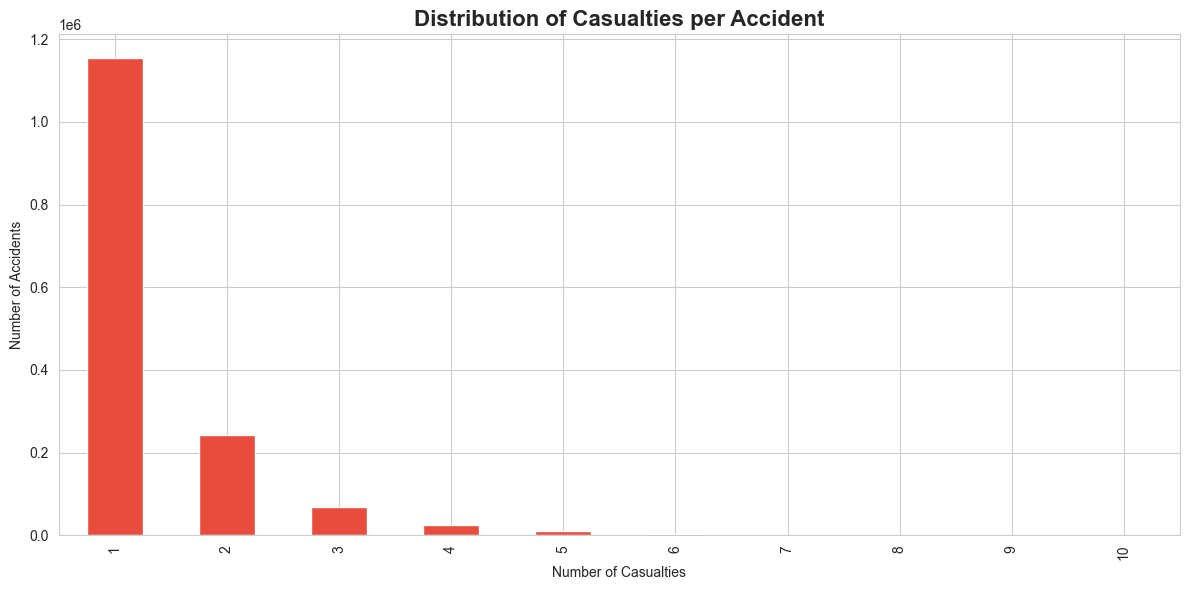

Chart 6 saved!


In [3]:
#Step 2: Distribution of Number of Casualties
plt.figure(figsize=(12,6))
df['Number_of_Casualties'].value_counts().sort_index().head(10).plot(kind='bar', color='#E74C3C')
plt.title('Distribution of Casualties per Accident', fontsize=16, fontweight='bold')
plt.xlabel('Number of Casualties')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.savefig('chart6_casualties_dist.png', dpi=150)
plt.show()
print("Chart 6 saved!")

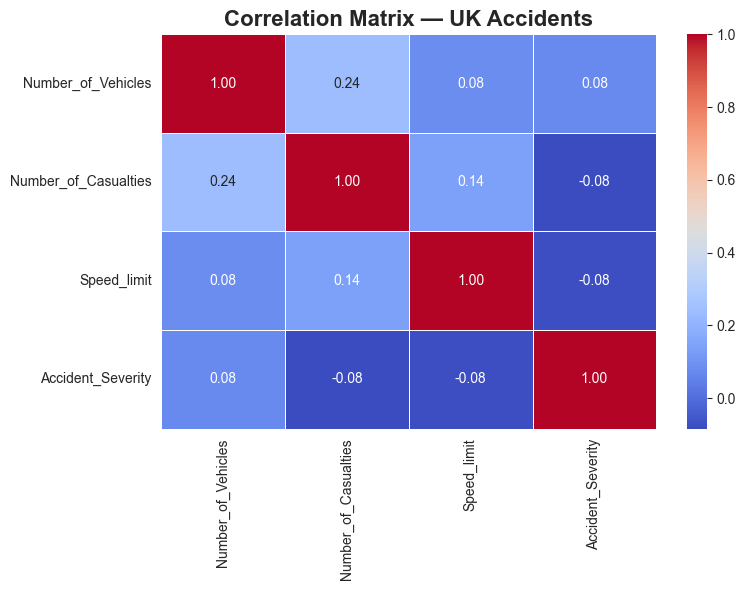

Chart 7 saved!


In [4]:
#Step 3: Correlation between numeric columns
numeric_cols = ['Number_of_Vehicles', 'Number_of_Casualties', 
                'Speed_limit', 'Accident_Severity']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — UK Accidents', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_correlation.png', dpi=150)
plt.show()
print("Chart 7 saved!")

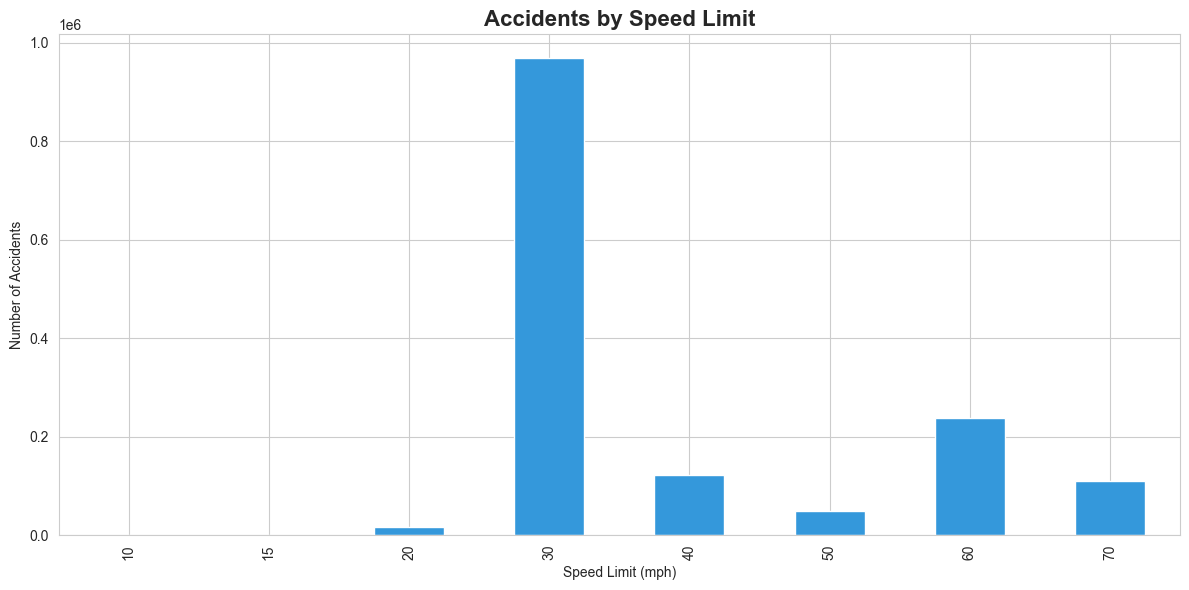

Chart 8 saved!


In [5]:
#Step 4: Speed limit distribution
plt.figure(figsize=(12,6))
df['Speed_limit'].value_counts().sort_index().plot(kind='bar', color='#3498DB')
plt.title('Accidents by Speed Limit', fontsize=16, fontweight='bold')
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.savefig('chart8_speed_limit.png', dpi=150)
plt.show()
print("Chart 8 saved!")

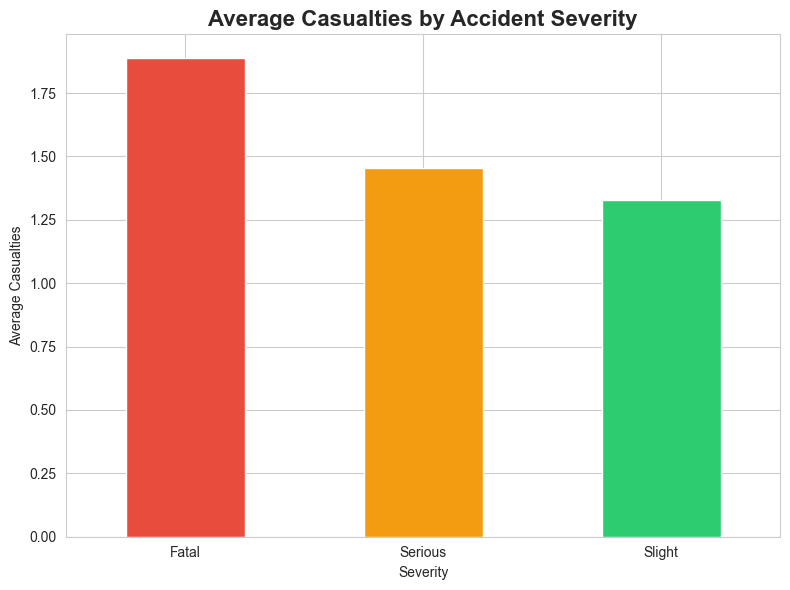

Chart 9 saved!


In [6]:
#Step 5: Average casualties by severity
avg_casualties = df.groupby('Accident_Severity')['Number_of_Casualties'].mean()
severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
avg_casualties.index = [severity_labels[i] for i in avg_casualties.index]

plt.figure(figsize=(8,6))
avg_casualties.plot(kind='bar', color=['#E74C3C', '#F39C12', '#2ECC71'])
plt.title('Average Casualties by Accident Severity', fontsize=16, fontweight='bold')
plt.xlabel('Severity')
plt.ylabel('Average Casualties')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart9_avg_casualties.png', dpi=150)
plt.show()
print("Chart 9 saved!")

In [7]:
#Step 6: Key statistical findings
print("=" * 50)
print("KEY STATISTICAL FINDINGS")
print("=" * 50)
print(f"Mean casualties per accident: {df['Number_of_Casualties'].mean():.2f}")
print(f"Max casualties in one accident: {df['Number_of_Casualties'].max()}")
print(f"Most common speed limit: {df['Speed_limit'].mode()[0]} mph")
print(f"Correlation (vehicles vs casualties): {df['Number_of_Vehicles'].corr(df['Number_of_Casualties']):.3f}")
print(f"Correlation (speed vs severity): {df['Speed_limit'].corr(df['Accident_Severity']):.3f}")

KEY STATISTICAL FINDINGS
Mean casualties per accident: 1.35
Max casualties in one accident: 93
Most common speed limit: 30 mph
Correlation (vehicles vs casualties): 0.237
Correlation (speed vs severity): -0.079
